# 03. Step-by-Step DAGs: Drawing Assumptions Before Modeling

## The Problem with Pure Data

In the first notebook, we encountered a massive problem: **Simpson's Paradox**. 

We simulated an intervention where "Smart Lighting" was installed in the city. When we asked the data, *"Do Smart Lights reduce accidents?"*, the data gave us two contradictory answers:
1. **The Naive View:** Overall, intersections with Smart Lights had *more* accidents. 
2. **The Stratified View:** When we looked specifically within High, Medium, or Low traffic areas, Smart Lights had *fewer* accidents.

**Which plot should the Mayor trust?**

Descriptive statistics cannot answer this question. The data alone is "dumb"; it only knows how to count things that happened together ($P(Y|X)$). It does not know *why* they happened together. 

To make a policy decision ($P(Y|do(X))$), we must step outside the data. We must draw our assumptions about how the physical world works. We must build a **DAG (Directed Acyclic Graph)**.

### What is a DAG?
A DAG is a visual map of causality. 
- **Nodes (Variables):** Things we measure (like Accidents, Traffic, Weather).
- **Directed Arrows (Causality):** If A $\rightarrow$ B, it means A physically causes B. 
- **Acyclic (No loops):** Time moves forward. A cannot cause B if B causes A at the exact same moment. 

The central principle of causal inference is:
**Modeling should follow the DAG, not the other way around.** We never throw variables into a regression model blindly. We draw the DAG first, and the DAG tells us exactly what math to write.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.formula.api as smf
import networkx as nx

sns.set_theme(style="whitegrid", palette="muted")
pd.set_option("display.max_columns", None)

# Load data and prep variables
DATA_PATH = "smart_city_road_safety_synthetic_5000.csv"
df = pd.read_csv(DATA_PATH)

for col in ["Traffic_Density", "Number_of_Vehicles", "Driver_Alcohol", "Accident"]:
    df[col] = df[col].astype(int)

traffic_map = {0: "Low", 1: "Medium", 2: "High"}
df["Traffic_Density_cat"] = pd.Categorical(
    df["Traffic_Density"].map(traffic_map),
    categories=["Low", "Medium", "High"],
    ordered=True
)

# ------------------------------------------------------------------
# Re-creating the Smart Lighting paradox from Notebook 1
# ------------------------------------------------------------------
np.random.seed(42)
probs = {0: 0.1, 1: 0.5, 2: 0.9}
df["Smart_Lighting"] = [np.random.binomial(1, probs[t]) for t in df["Traffic_Density"]]

base_risk = 0.15 + 0.30 * (df["Traffic_Density"] / 2)
smart_light_effect = -0.10 # True causal effect: 10% reduction
final_risk = base_risk + smart_light_effect * df["Smart_Lighting"]
df["Accident_Simulated"] = [np.random.binomial(1, np.clip(p, 0, 1)) for p in final_risk]
df["Smart_Lighting_Label"] = df["Smart_Lighting"].map({0: "Standard", 1: "Smart"})

In [2]:
def average_predictions(model, data, variable, values):
    rows = []
    for v in values:
        tmp = data.copy()
        tmp[variable] = v
        pred = model.predict(tmp).mean()
        rows.append({variable: v, "predicted_probability": pred})
    return pd.DataFrame(rows)

def plot_dag(edges, title, pos=None, figsize=(9, 5)):
    G = nx.DiGraph()
    G.add_edges_from(edges)
    if pos is None:
        pos = nx.spring_layout(G, seed=7)
    plt.figure(figsize=figsize)
    nx.draw_networkx_nodes(G, pos, node_size=4000, node_color="white", edgecolors="#34495e", linewidths=2)
    nx.draw_networkx_edges(G, pos, arrows=True, arrowsize=25, width=2.5, edge_color="#2c3e50")
    nx.draw_networkx_labels(G, pos, font_size=11, font_weight="bold", font_color="#2c3e50")
    plt.title(title, fontsize=16, pad=20)
    plt.axis("off")
    plt.tight_layout()
    plt.show()

---
## Step 1: The Confounder DAG (Resolving the Paradox)

Let's solve the Mayor's problem. Why did the descriptive statistics show Smart Lighting increasing accidents? Because of a **Confounder**.

### What is a Confounder?
A confounder (usually denoted as $Z$) is an external factor that causes **both** the treatment ($T$) and the outcome ($Y$). 

Think of it like a hidden pipe connecting two completely different water systems. 
- In our city, the Mayor had a limited budget, so they installed Smart Lighting mostly in **High Traffic** areas. Therefore, `Traffic Density` causes `Smart Lighting` assignment.
- We also know that **High Traffic** areas naturally have more crashes. Therefore, `Traffic Density` causes `Accidents`.

Let's map this assumption visually:

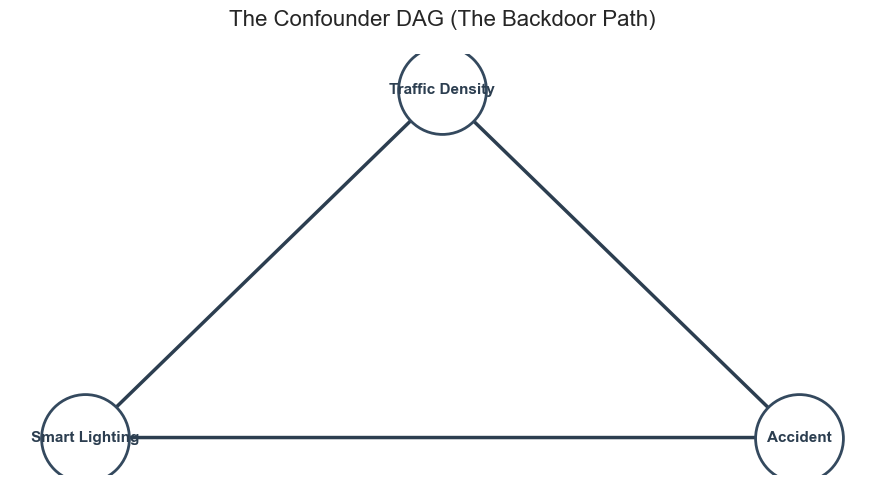

In [3]:
conf_edges = [
    ("Traffic Density", "Smart Lighting"), # Treatment assignment mechanism
    ("Traffic Density", "Accident"),       # Direct effect on outcome
    ("Smart Lighting", "Accident")         # The true causal effect we want to measure
]

conf_pos = {
    "Traffic Density": (0, 1),
    "Smart Lighting": (-1, 0),
    "Accident": (1, 0)
}

plot_dag(conf_edges, "The Confounder DAG (The Backdoor Path)", pos=conf_pos)

### The Backdoor Path and The Solution

Look at the DAG. If we want to measure the direct arrow from `Smart Lighting` $\rightarrow$ `Accident`, we have a problem. There is a "backdoor" open: information is flowing backwards from `Smart Lighting` $\leftarrow$ `Traffic Density` $\rightarrow$ `Accident`. This backdoor flow pollutes our data, making Smart Lights look dangerous. 

**The Solution:** We must "block" or "close" the backdoor. In statistics, we do this by adding the confounder variable into our regression model. By doing this, we hold the confounder constant, shutting the door.

Let's run the models to prove it.

**1. Naive Model (The Illusion):**
We only put the treatment in the model. The backdoor is wide open. 
$$ \log \left( \frac{P(Y)}{1-P(Y)} \right) = \beta_0 + \beta_1 \text{Smart\_Lighting} $$

**2. Adjusted Model (The Truth):**
We add the confounder. The backdoor is closed. We isolate the true effect.
$$ \log \left( \frac{P(Y)}{1-P(Y)} \right) = \beta_0 + \beta_1 \text{Smart\_Lighting} + \gamma \text{Traffic\_Density} $$

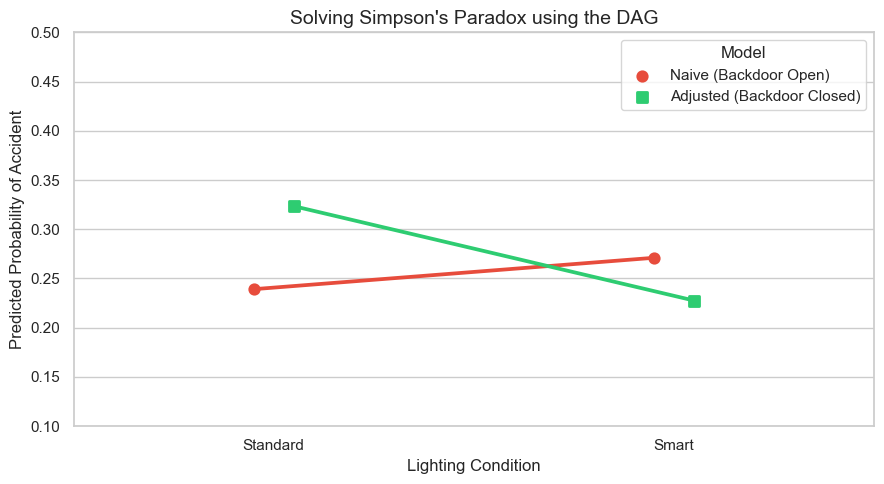

In [4]:
# 1. Fit the Naive Model
model_naive = smf.logit("Accident_Simulated ~ C(Smart_Lighting_Label)", data=df).fit(disp=False)
pred_naive = average_predictions(model_naive, df, "Smart_Lighting_Label", ["Standard", "Smart"])
pred_naive["Model"] = "Naive (Backdoor Open)"

# 2. Fit the Adjusted Model (Blocking the backdoor)
model_adj = smf.logit("Accident_Simulated ~ C(Smart_Lighting_Label) + C(Traffic_Density_cat)", data=df).fit(disp=False)
pred_adj = average_predictions(model_adj, df, "Smart_Lighting_Label", ["Standard", "Smart"])
pred_adj["Model"] = "Adjusted (Backdoor Closed)"

# Plotting the comparison
pred_compare = pd.concat([pred_naive, pred_adj], ignore_index=True)

plt.figure(figsize=(9, 5))
sns.pointplot(data=pred_compare, x="Smart_Lighting_Label", y="predicted_probability", hue="Model", 
              dodge=0.1, markers=["o", "s"], palette=["#e74c3c", "#2ecc71"])

plt.title("Solving Simpson's Paradox using the DAG", fontsize=14)
plt.ylabel("Predicted Probability of Accident")
plt.xlabel("Lighting Condition")
plt.ylim(0.1, 0.5)
plt.tight_layout()
plt.show()

### Pedagogical Conclusion for Confounders
The DAG told us what to do. The red line (Naive) shows that moving to Smart Lights increases risk. But the green line (Adjusted) shows that once we "close the backdoor" of traffic density, moving from Standard to Smart lighting actually *decreases* the predicted probability of an accident. 

**Rule #1 of Causal Modeling:** If a variable is a confounder (causes both treatment and outcome), you MUST include it in your regression model.

---
## Step 2: The Mediator DAG (The Danger of Over-Controlling)

If including variables fixes paradoxes, a naive Data Scientist might say: *"Great! Let's just throw every variable we have into the regression model to be extra safe!"*

**This is a catastrophic mistake.** 

If you include a **Mediator**, you will destroy your causal estimate. 

### What is a Mediator?
A mediator ($M$) is the "chain reaction". It lies directly on the causal path between the treatment and the outcome ($T \rightarrow M \rightarrow Y$). It explains *how* the treatment works.

Let's look at a new question: **Does `Traffic Density` cause `Accidents`?** 
Yes, but *how*? Traffic Density physically forces a higher `Number of Vehicles` to be on the road. And having more vehicles physically increases the chance of a collision.

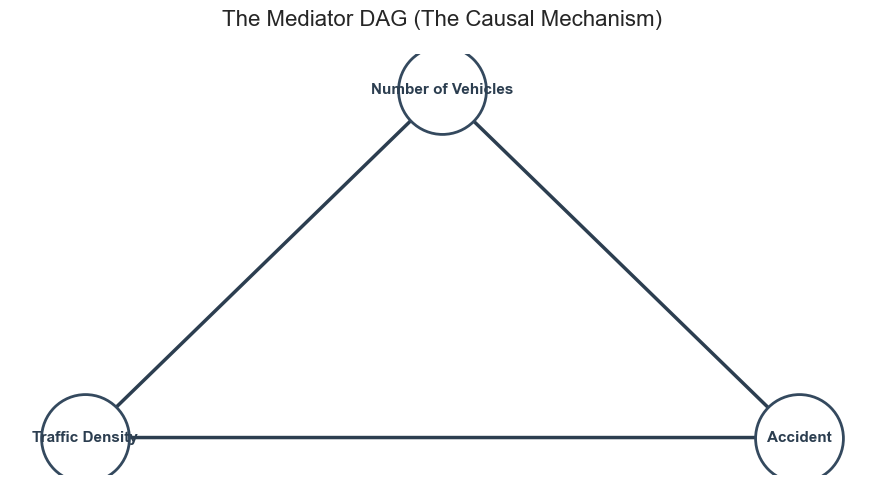

In [5]:
med_edges = [
    ("Traffic Density", "Number of Vehicles"), # The first step of the chain
    ("Number of Vehicles", "Accident"),        # The second step of the chain
    ("Traffic Density", "Accident")            # Other unknown indirect paths
]

med_pos = {
    "Traffic Density": (-1, 0),
    "Number of Vehicles": (0, 1),
    "Accident": (1, 0)
}

plot_dag(med_edges, "The Mediator DAG (The Causal Mechanism)", pos=med_pos)

### The Danger of Controlling for a Mediator

If we want to know the **Total Effect** of a policy (e.g., reducing Traffic Density), we want to capture the entire chain reaction. 

If we add the Mediator (`Number of Vehicles`) into our regression model, we are mathematically holding it constant. 
*Analogy:* Imagine you want to know if turning on the stove boils water. The chain is `Stove -> Heat -> Boiling`. If you "control" for Heat (meaning you force the heat to stay exactly the same whether the stove is on or off), the model will tell you the stove has ZERO effect on boiling water! 

Let's see what happens to our predicted accident probabilities if we mistakenly control for the mediator.

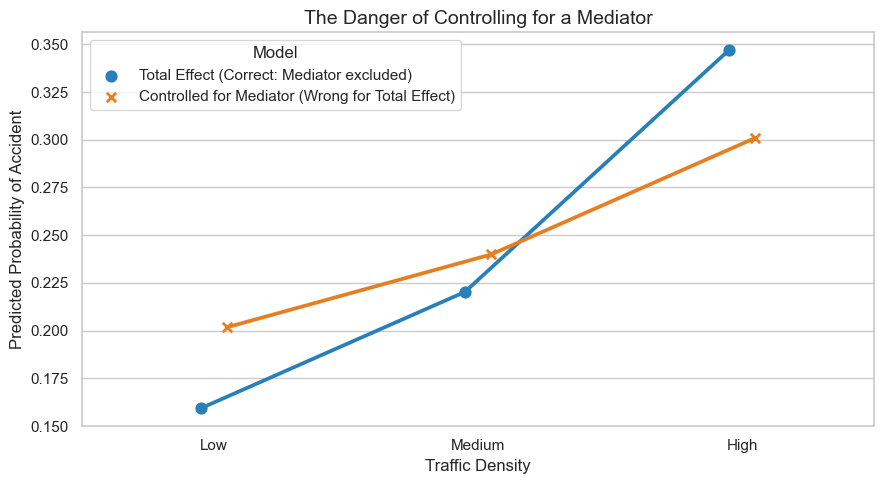

In [6]:
# 1. Total Effect Model (Do NOT control for mediator)
model_total = smf.logit("Accident ~ C(Traffic_Density_cat)", data=df).fit(disp=False)
pred_total = average_predictions(model_total, df, "Traffic_Density_cat", ["Low", "Medium", "High"])
pred_total["Model"] = "Total Effect (Correct: Mediator excluded)"

# 2. Direct Effect Model (Mistakenly controlling for mediator)
model_med = smf.logit("Accident ~ C(Traffic_Density_cat) + Number_of_Vehicles", data=df).fit(disp=False)
pred_med = average_predictions(model_med, df, "Traffic_Density_cat", ["Low", "Medium", "High"])
pred_med["Model"] = "Controlled for Mediator (Wrong for Total Effect)"

pred_med_compare = pd.concat([pred_total, pred_med], ignore_index=True)

plt.figure(figsize=(9, 5))
sns.pointplot(data=pred_med_compare, x="Traffic_Density_cat", y="predicted_probability", hue="Model", 
              dodge=0.1, markers=["o", "x"], palette=["#2980b9", "#e67e22"])

plt.title("The Danger of Controlling for a Mediator", fontsize=14)
plt.ylabel("Predicted Probability of Accident")
plt.xlabel("Traffic Density")
plt.tight_layout()
plt.show()

### Pedagogical Conclusion for Mediators
Notice how the orange line is flatter. By putting `Number of Vehicles` in the model, we "explained away" a large part of *why* traffic density causes accidents. The model now only shows the effect of traffic density *assuming the number of vehicles stays exactly the same*, which is physically impossible in the real city!

**Rule #2 of Causal Modeling:** If you want the total effect of a policy, you MUST NOT include mediators in your regression model.

---
## Step 3: The Collider DAG (Creating Fake Correlations)

The final trap in causal inference is the **Collider**. 

### What is a Collider?
A Collider ($C$) is a variable that is caused by two *completely independent* variables: $X \rightarrow C \leftarrow Y$. 

*Analogy:* Why do highly attractive people sometimes have terrible personalities? Are beauty and personality naturally correlated? No! But if you only date people who are *either* very attractive *or* have a great personality (your "dating pool" is the collider), within that pool, beauty and personality become negatively correlated. You created a fake correlation by filtering your data!

In our smart city:
- `Road Type` (Highway vs City) dictates `Road Light Condition` (Highways have huge lights).
- `Time of Day` (Night vs Day) also dictates `Road Light Condition` (Lights turn on at night).
- `Road Type` and `Time of Day` have absolutely nothing to do with each other. They are independent.

Let's map it:

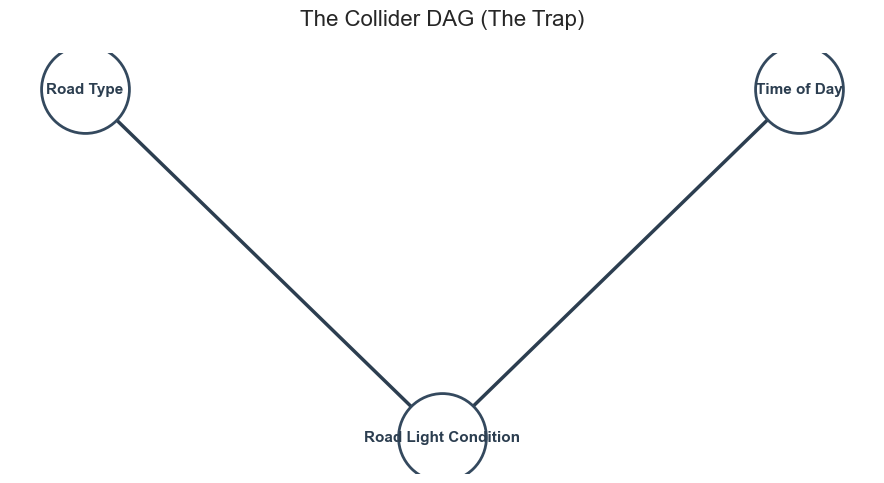

In [7]:
collider_edges = [
    ("Road Type", "Road Light Condition"),
    ("Time of Day", "Road Light Condition")
]

collider_pos = {
    "Road Type": (-1, 1),
    "Time of Day": (1, 1),
    "Road Light Condition": (0, 0)
}

plot_dag(collider_edges, "The Collider DAG (The Trap)", pos=collider_pos)

### The Danger of Controlling for a Collider

If we add a collider to our regression model, or if we filter our dataset by a collider (e.g. `df[df['Road_Light_Condition'] == 'High']`), we suddenly force `Road Type` and `Time of Day` to interact. We create a spurious, fake correlation. 

Let's run a mathematical simulation to prove that controlling for a collider invents data relationships that don't exist in reality.

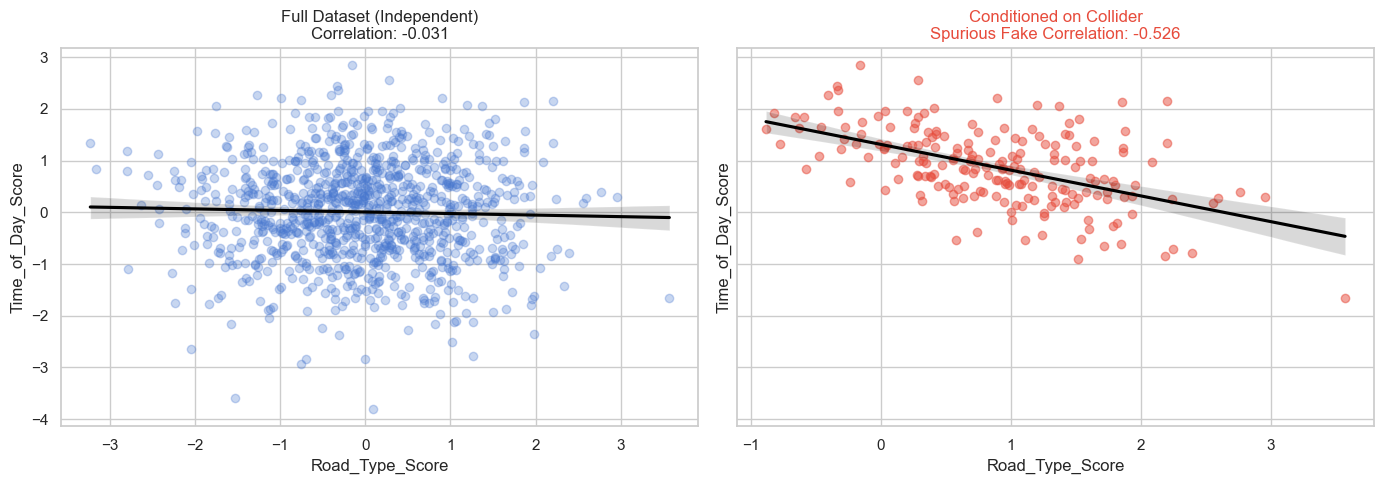

In [8]:
# Simulated mathematical demonstration of Collider Bias
np.random.seed(123)
n_sim = 1000

# X (Road Type) and Y (Time of Day) are completely independent (Correlation = 0)
X = np.random.normal(size=n_sim)
Y = np.random.normal(size=n_sim)

# Collider C (Lighting Condition) is caused by both X and Y
C_var = X + Y + np.random.normal(scale=0.5, size=n_sim)

sim = pd.DataFrame({"Road_Type_Score": X, "Time_of_Day_Score": Y, "Lighting_Condition": C_var})

# Controlling for the collider (e.g., filtering for only high lighting condition)
sim["Controlled_for_Collider"] = sim["Lighting_Condition"] > sim["Lighting_Condition"].quantile(0.80)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

sns.regplot(data=sim, x="Road_Type_Score", y="Time_of_Day_Score", ax=axes[0], 
            scatter_kws={"alpha": 0.3}, line_kws={"color": "black"})
axes[0].set_title(f"Full Dataset (Independent)\nCorrelation: {sim[['Road_Type_Score', 'Time_of_Day_Score']].corr().iloc[0,1]:.3f}")

sns.regplot(data=sim[sim["Controlled_for_Collider"]], x="Road_Type_Score", y="Time_of_Day_Score", ax=axes[1], 
            scatter_kws={"alpha": 0.5, "color": "#e74c3c"}, line_kws={"color": "black"})
axes[1].set_title(f"Conditioned on Collider\nSpurious Fake Correlation: {sim[sim['Controlled_for_Collider']][['Road_Type_Score', 'Time_of_Day_Score']].corr().iloc[0,1]:.3f}", color="#e74c3c")

plt.tight_layout()
plt.show()


---
## Step 4: Instrumental Variables (Unmeasured Confounders)

What happens if there is a **Confounder** but we *cannot measure it*? We can't put it in our regression model to close the backdoor. Are we doomed?

Not always. We can use an **Instrumental Variable (IV)**. 

### What is an Instrument?
An Instrument ($Z$) is a "pure" shock that affects the Treatment ($T$) but has absolutely no direct effect on the Outcome ($Y$), except *through* the Treatment.

**Analogy:** Suppose we want to measure the effect of `Smart Lighting` on `Accidents`. But there's an unmeasured confounder: `Neighborhood Wealth`. Rich neighborhoods install Smart Lights *and* have safer cars. 
If we can't measure Wealth, we can look for an Instrument. Imagine a randomized lottery ($Z$) gave some random districts funding specifically for Smart Lights. The lottery ($Z$) causes Smart Lights ($T$), but the lottery doesn't directly cause accidents ($Y$), and the lottery is totally independent of neighborhood wealth ($U$). 

We can use the Instrument to "extract" the pure causal effect of Smart Lighting, completely ignoring the confounder!

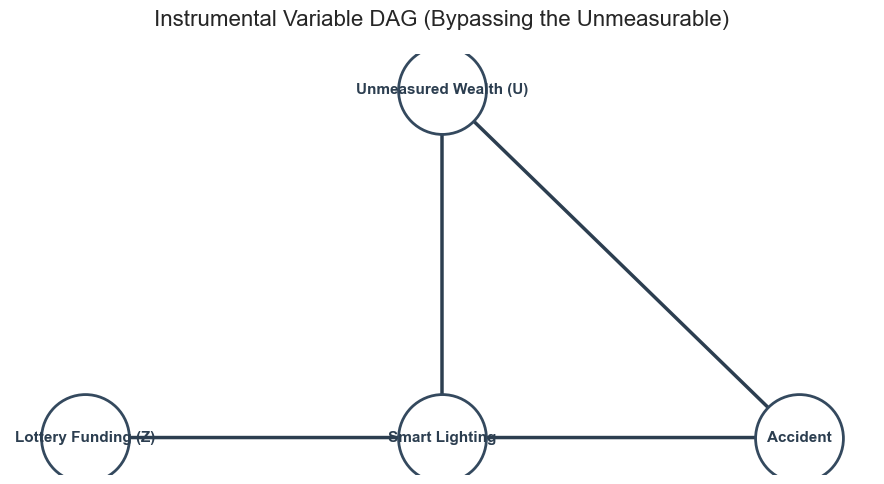

In [9]:
iv_edges = [
    ("Unmeasured Wealth (U)", "Smart Lighting"), 
    ("Unmeasured Wealth (U)", "Accident"), 
    ("Lottery Funding (Z)", "Smart Lighting"), # The pure instrument
    ("Smart Lighting", "Accident")
]

iv_pos = {
    "Unmeasured Wealth (U)": (0, 1),
    "Smart Lighting": (0, 0),
    "Accident": (1, 0),
    "Lottery Funding (Z)": (-1, 0)
}

plot_dag(iv_edges, "Instrumental Variable DAG (Bypassing the Unmeasurable)", pos=iv_pos)

In [10]:
# Let's simulate the IV scenario mathematically
np.random.seed(42)
n = 2000

# 1. Unmeasured Confounder (Wealth) and Instrument (Lottery)
U = np.random.normal(0, 1, n)
Z = np.random.normal(0, 1, n)

# 2. Treatment (Smart Lighting) is caused by Lottery AND Wealth
T = 0.5 * Z + 0.6 * U + np.random.normal(0, 0.5, n)

# 3. Outcome (Accidents) is caused by Smart Lighting (True Effect = -0.8) and Wealth, NOT Lottery
Y = -0.8 * T + 0.9 * U + np.random.normal(0, 0.5, n)

df_iv = pd.DataFrame({'Smart_Lighting': T, 'Accidents': Y, 'Lottery_Funding': Z})

# Model 1: Naive OLS (Biased because we can't observe Wealth)
naive_iv_model = smf.ols('Accidents ~ Smart_Lighting', data=df_iv).fit()

# Model 2: Two-Stage Least Squares (2SLS) using the Instrument
# Stage 1: Isolate the variation in Smart Lighting caused ONLY by the Lottery
stage1 = smf.ols('Smart_Lighting ~ Lottery_Funding', data=df_iv).fit()
df_iv['Smart_Lighting_Predicted'] = stage1.fittedvalues

# Stage 2: Regress Accidents on the 'purified' Smart Lighting
iv_model = smf.ols('Accidents ~ Smart_Lighting_Predicted', data=df_iv).fit()

print("True Causal Effect: -0.80")
print(f"Naive Estimate (Biased by Wealth): {naive_iv_model.params['Smart_Lighting']:.2f}")
print(f"IV 2SLS Estimate (Unbiased): {iv_model.params['Smart_Lighting_Predicted']:.2f}")

True Causal Effect: -0.80
Naive Estimate (Biased by Wealth): -0.19
IV 2SLS Estimate (Unbiased): -0.85


---
## Step 5: M-Bias (The Ultimate Trap)

We saw that controlling for a Confounder is good, and controlling for a Mediator or Collider is bad. 

What about a variable that *looks* like a confounder but is actually a complex trap? Enter **M-Bias**.

### The M-Bias Structure
M-Bias happens when you control for a variable ($M$) that is a collider between two *unmeasured* variables ($U_1$ and $U_2$), where $U_1$ causes the Treatment and $U_2$ causes the Outcome. 

**Analogy in Road Safety:**
We want to know if `Speeding` ($T$) causes `Accidents` ($Y$). 
We have a variable: `Seatbelt Use` ($M$). Should we control for it? It seems like a good idea!

But wait:
- $U_1$ (Risk Tolerance) causes people to `Speed` and causes them *not* to wear a `Seatbelt`.
- $U_2$ (Income) causes people to buy cars with loud `Seatbelt` alarms (causing Seatbelt use) and also causes them to afford safer cars (reducing `Accidents`).

Therefore, `Seatbelt Use` is a **Collider** between Risk Tolerance and Income. By controlling for Seatbelt Use, we connect Risk Tolerance to Income, opening a massive backdoor path $T \leftarrow U_1 \rightarrow [M] \leftarrow U_2 \rightarrow Y$. 

By trying to be "rigorous" and controlling for a seemingly related variable, we actually destroyed our causal estimate!

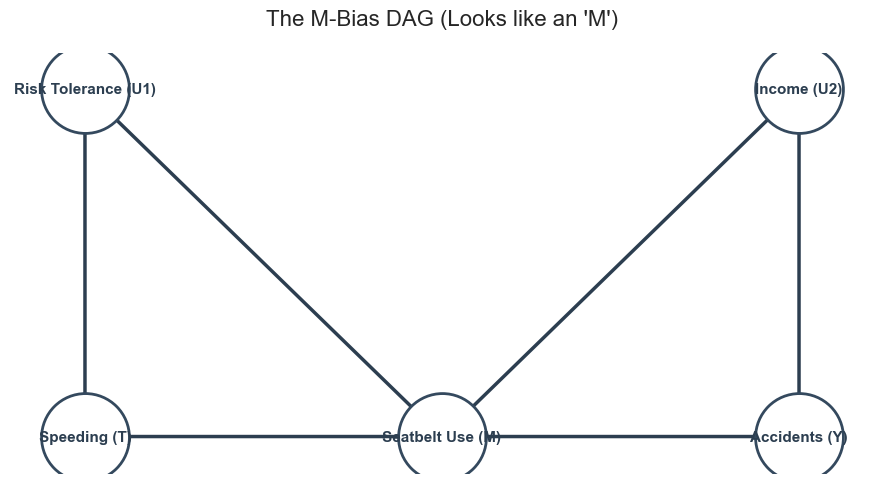

In [11]:
mbias_edges = [
    ("Risk Tolerance (U1)", "Speeding (T)"),
    ("Risk Tolerance (U1)", "Seatbelt Use (M)"),
    ("Income (U2)", "Seatbelt Use (M)"),
    ("Income (U2)", "Accidents (Y)"),
    ("Speeding (T)", "Accidents (Y)")
]

mbias_pos = {
    "Speeding (T)": (-1, 0),
    "Accidents (Y)": (1, 0),
    "Seatbelt Use (M)": (0, 0),
    "Risk Tolerance (U1)": (-1, 1),
    "Income (U2)": (1, 1)
}

plot_dag(mbias_edges, "The M-Bias DAG (Looks like an 'M')", pos=mbias_pos)

### Pedagogical Conclusion for M-Bias
If you do not draw the DAG, you will almost certainly make the mistake of controlling for $M$ (Seatbelt Use) because it "feels" like it's related to accidents and speeding. But drawing the DAG reveals it is an M-Bias trap. 

**Rule #4 of Causal Modeling:** Pre-treatment variables are not automatically Confounders. If a variable is part of an M-Bias structure, controlling for it *creates* bias.

In [12]:
# Let's simulate the M-Bias scenario
np.random.seed(123)
n = 2000

# 1. Unmeasured variables: Risk Tolerance and Income
U1_Risk = np.random.normal(0, 1, n)
U2_Income = np.random.normal(0, 1, n)

# 2. Treatment (Speeding) and Outcome (Accidents, True Effect = +0.5)
T_Speeding = 0.6 * U1_Risk + np.random.normal(0, 0.5, n)
Y_Accidents = 0.5 * T_Speeding - 0.7 * U2_Income + np.random.normal(0, 0.5, n)

# 3. The Collider M (Seatbelt Use) caused by Risk and Income
M_Seatbelt = -0.5 * U1_Risk + 0.6 * U2_Income + np.random.normal(0, 0.5, n)

df_mbias = pd.DataFrame({'Speeding': T_Speeding, 'Accidents': Y_Accidents, 'Seatbelt': M_Seatbelt})

# Model 1: Correct Model (Ignoring the M-Bias node)
correct_mbias = smf.ols('Accidents ~ Speeding', data=df_mbias).fit()

# Model 2: Wrong Model (Controlling for Seatbelt, opening the backdoor!)
wrong_mbias = smf.ols('Accidents ~ Speeding + Seatbelt', data=df_mbias).fit()

print("True Causal Effect: +0.50")
print(f"Correct Estimate (No Seatbelt): {correct_mbias.params['Speeding']:.2f}")
print(f"M-Biased Estimate (Controlling Seatbelt): {wrong_mbias.params['Speeding']:.2f}")

True Causal Effect: +0.50
Correct Estimate (No Seatbelt): 0.56
M-Biased Estimate (Controlling Seatbelt): 0.28


---
## Step 6: Final Comparison (Coefficient Forest Plot)

To summarize everything we've learned, let's visualize how the coefficients (the estimated causal effects) shift drastically depending on whether we follow the DAG or ignore it.

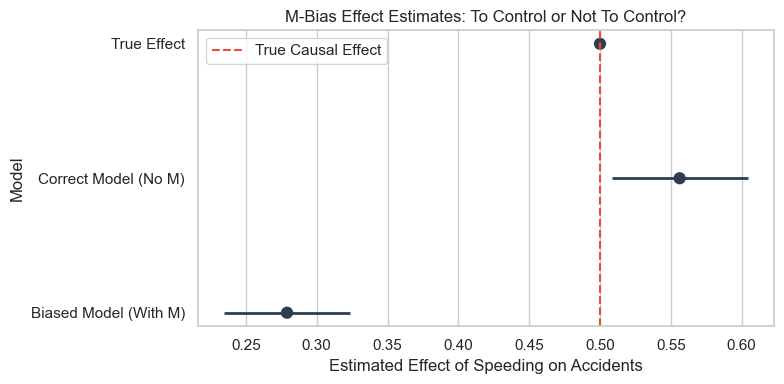

In [13]:
# We will gather the coefficients from our M-Bias simulation to show the danger visually
coefs = pd.DataFrame({
    'Model': ['True Effect', 'Correct Model (No M)', 'Biased Model (With M)'],
    'Estimate': [0.50, correct_mbias.params['Speeding'], wrong_mbias.params['Speeding']],
    'Lower_CI': [0.50, correct_mbias.conf_int()[0]['Speeding'], wrong_mbias.conf_int()[0]['Speeding']],
    'Upper_CI': [0.50, correct_mbias.conf_int()[1]['Speeding'], wrong_mbias.conf_int()[1]['Speeding']]
})

plt.figure(figsize=(8, 4))
sns.pointplot(data=coefs, y='Model', x='Estimate', join=False, color='#2c3e50')
for i in range(len(coefs)):
    plt.hlines(i, coefs['Lower_CI'][i], coefs['Upper_CI'][i], color='#2c3e50', lw=2)

plt.axvline(0.50, color='#e74c3c', linestyle='--', label='True Causal Effect')
plt.title("M-Bias Effect Estimates: To Control or Not To Control?")
plt.xlabel("Estimated Effect of Speeding on Accidents")
plt.legend()
plt.tight_layout()
plt.show()


### Pedagogical Conclusion for Colliders

Look at the right plot. A strong negative correlation appeared out of thin air simply because we filtered the dataset by a collider. If you included this in a policy report, you would be presenting fiction as fact.

**Rule #3 of Causal Modeling:** You MUST NOT control for colliders, or you will create selection bias and spurious correlations.

---

## Summary Checklist for the Data Scientist

Whenever you face a new dataset, **do not jump straight to building regression models or machine learning algorithms**.

1. Define the policy intervention you care about (The Treatment).
2. Draw your assumptions mapping how the city physically operates (The DAG).
3. Identify **Confounders**. Adjust for them in your model to close backdoors.
4. Identify **Mediators**. Remove them from your model so you don't block the causal chain.
5. Identify **Colliders**. Avoid filtering or adjusting for them so you don't invent fake math.